## Import librerie e dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("TMDB_movie_dataset_v11.csv")
df.shape

(1387276, 24)

In [3]:
pd.set_option('display.max_columns', None)

df.head()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,budget,homepage,imdb_id,original_language,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,160000000,https://www.warnerbros.com/movies/inception,tt1375666,en,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,165000000,http://www.interstellarmovie.net/,tt0816692,en,Interstellar,The adventures of a group of explorers who mak...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,185000000,https://www.warnerbros.com/movies/dark-knight/,tt0468569,en,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,237000000,https://www.avatar.com/movies/avatar,tt0499549,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.932,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,220000000,https://www.marvel.com/movies/the-avengers,tt0848228,en,The Avengers,When an unexpected enemy emerges and threatens...,98.082,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."


In [4]:
df["status"].value_counts()

status
Released           1339413
In Production        21298
Post Production      14543
Planned              10947
Rumored                714
Canceled               361
Name: count, dtype: int64

## Filtraggio dataset
Manteniamo solo i film con status "Released" perché vogliamo addestrare 
il modello su dati reali e completi. Film in produzione o non ancora 
usciti hanno revenue = 0, il che falsificherebbe le predizioni.

In [5]:
df = df[df["status"] == "Released"]
df.shape

(1339413, 24)

## Selezione delle feature
Teniamo solo le colonne utili per il modello

In [6]:
cols = ["revenue", "budget", "popularity", "runtime", "vote_average", "vote_count", "genres", "original_language", "release_date"]
df = df[cols]
df.shape

(1339413, 9)

In [7]:
df.isnull().sum()

revenue                   0
budget                    0
popularity                0
runtime                   0
vote_average              0
vote_count                0
genres               590774
original_language         0
release_date         271419
dtype: int64

In [8]:
(df["revenue"] == 0).sum()

np.int64(1315886)

In [10]:
df = df[df["revenue"] > 0]
df.shape

(23526, 9)

In [12]:
(df["budget"] == 0).sum()

np.int64(6844)

In [13]:
df = df[df["budget"] > 0]
df.shape

(16682, 9)

In [14]:
df.isnull().sum()

revenue                 0
budget                  0
popularity              0
runtime                 0
vote_average            0
vote_count              0
genres               2918
original_language       0
release_date         3056
dtype: int64

In [15]:
df = df.dropna(subset=["genres", "release_date"])
df.shape

(13147, 9)

## Pulizia del dataset
Rimossi i film con revenue o budget pari a 0 (dati non disponibili).
Rimossi i film con valori mancanti in genres e release_date perchè sono feature importanti per il modello, 
imputarle con valori fittizi introdurrebbe rumore nel modello

# <br>
# <br>

## Analisi Esplorativa e Pulizia dei Dati

In [16]:
df.describe()

,revenue,budget,popularity,runtime,vote_average,vote_count
count,1.314700e+04,1.314700e+04,13147.000000,13147.000000,13147.000000,13147.000000
mean,5.471020e+07,1.893738e+07,14.872103,89.838290,5.484506,1163.284476
std,1.594525e+08,3.795723e+07,54.351411,54.908697,2.804520,2678.463271
min,1.000000e+00,1.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,4.195150e+04,4.583900e+04,1.020500,81.000000,5.166500,1.000000
50%,4.922166e+06,4.520000e+06,9.375000,99.000000,6.276000,150.000000
75%,3.860500e+07,2.000000e+07,17.640000,116.000000,7.040500,1034.500000
max,5.000000e+09,8.000000e+08,2994.357000,999.000000,10.000000,34495.000000


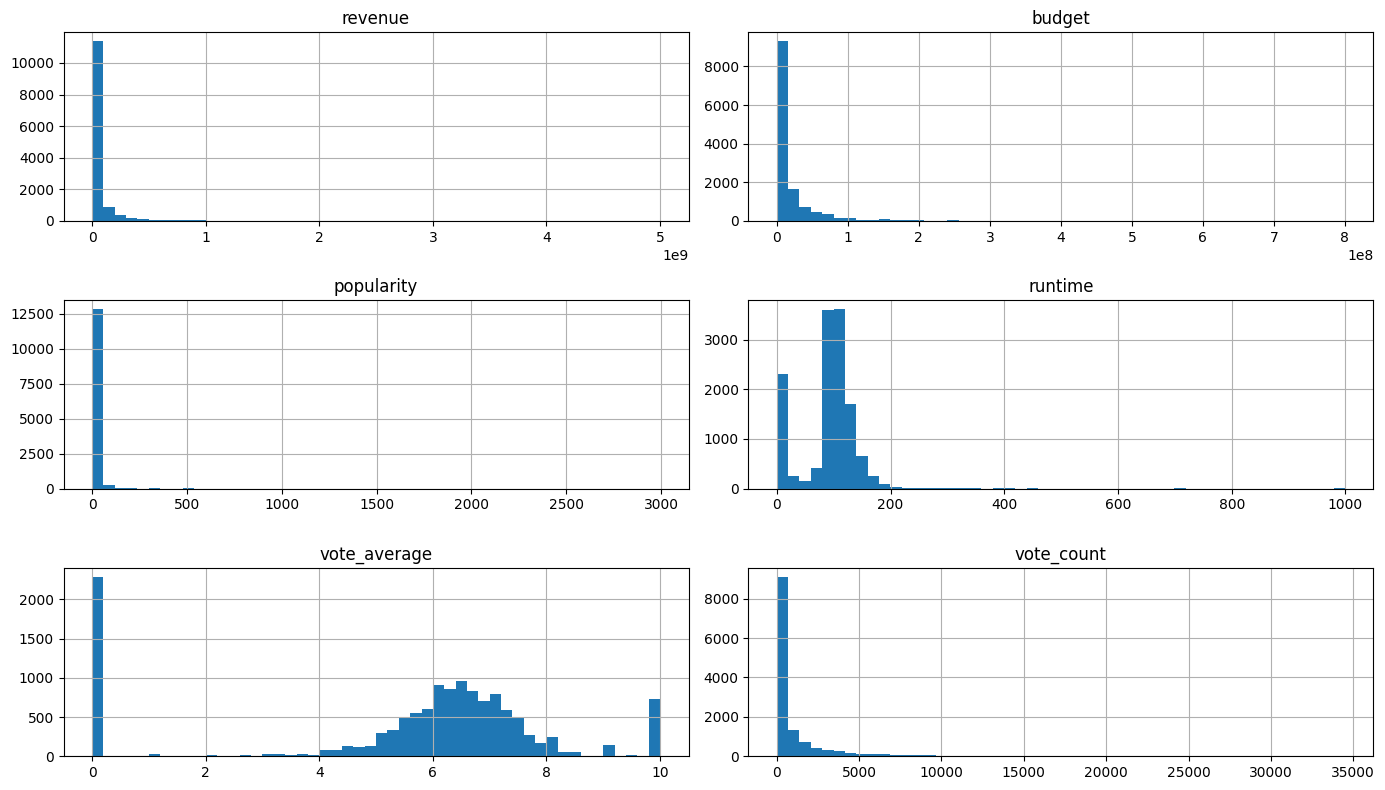

In [17]:
df.hist(bins=50, figsize=(14, 8))
plt.tight_layout()
plt.show()

In [18]:
df[df["runtime"] == 0].shape[0]

1041

In [19]:
df[df["runtime"] > 240].shape[0]

52

In [20]:
df[df["runtime"] > 240][["runtime", "revenue", "budget"]].sort_values("runtime", ascending=False).head(10)

,runtime,revenue,budget
348037,999,319700000,150000000
308424,999,469000000,200000000
308487,999,135395253,80000000
783394,999,479,111
297000,990,19,19
318843,987,495400000,10500000
184341,980,6,12
319199,975,40000000,7500000
646674,915,90,100
487076,800,40000,20000


In [21]:
df = df[(df["runtime"] > 0) & (df["runtime"] <= 240)]
df.shape

(12054, 9)

In [22]:
(df["vote_average"] == 0).sum()

np.int64(1608)

In [23]:
df[df["vote_average"] == 0]["vote_count"].describe()

count    1608.000000
mean        0.002488
std         0.049829
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: vote_count, dtype: float64

In [24]:
df[(df["vote_average"] == 0) & (df["vote_count"] == 1)]

,revenue,budget,popularity,runtime,vote_average,vote_count,genres,original_language,release_date
234193,100000,55000,0.600,98,0.0,1,"Drama, Romance",tr,1959-05-02
241827,1368000,690000,0.838,135,0.0,1,"Action, Drama, Romance",bn,2013-10-11
244464,3700000,120000,0.623,53,0.0,1,"Documentary, Music, Drama, History",en,2011-04-20
290218,200,200,0.720,14,0.0,1,"Romance, Drama",en,2023-04-25


In [25]:
df = df[df["vote_average"] > 0]
df.shape

(10446, 9)

In [26]:
(df["vote_count"] == 0).sum()

np.int64(2)

In [27]:
df = df[df["vote_count"] > 0]
df.shape

(10444, 9)

In [28]:
(df["popularity"] == 0).sum()

np.int64(84)

In [29]:
df = df[df["popularity"] > 0]
df.shape

(10360, 9)

In [33]:
df[df["budget"] < 10000]["budget"].sort_values().head(20)

346525    1
346540    1
346534    1
346532    1
250225    1
261963    1
260122    1
258738    1
252659    1
252671    1
61280     1
63238     1
273618    1
266406    1
266364    1
266338    1
59825     1
58410     1
331120    1
272132    1
Name: budget, dtype: int64

In [34]:
df[df["budget"] < 10000]["budget"].value_counts().sort_index()

budget
1       64
2       14
3       11
4        6
5       30
        ..
9811     1
9859     1
9888     1
9988     1
9990     1
Name: count, Length: 220, dtype: int64

In [35]:
df[df["revenue"] < 10000]["revenue"].value_counts().sort_index()

revenue
1       79
2       30
3       10
4       10
5       14
        ..
9885     1
9886     1
9887     1
9984     1
9988     1
Name: count, Length: 264, dtype: int64

In [37]:
df[["revenue", "budget"]].quantile([0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.08, 0.09, 0.10])

,revenue,budget
0.01,2.00,5.00
0.02,15.00,20.00
0.03,79.54,83.85
0.04,200.00,200.00
0.05,1000.00,1000.00
0.06,3863.18,3338.10
0.07,8533.56,7791.99
0.08,11526.12,10000.00
0.08,11526.12,10000.00
0.09,22308.19,25000.00


In [38]:
rev_5 = df["revenue"].quantile(0.05)
bud_5 = df["budget"].quantile(0.05)

df = df[(df["revenue"] >= rev_5) & (df["budget"] >= bud_5)]
df.shape

(9784, 9)

## Rimozione outlier e valori anomali
Rimossi i film con runtime = 0 e > 240 minuti, vote_average e vote_count = 0, popularity = 0 e i valori sotto il 5° percentile di revenue e budget, in quanto chiaramente dati errati o placeholder.